Left: 177.44, Right: 153.16, Separation: 15.77
Left: 178.09, Right: 168.96, Separation: 18.14
Left: 179.45, Right: 177.03, Separation: 18.93
Left: 179.36, Right: 177.71, Separation: 19.51
Left: 178.55, Right: 177.74, Separation: 20.0
Left: 175.15, Right: 177.59, Separation: 19.81
Left: 174.17, Right: 175.66, Separation: 19.13
Left: 174.82, Right: 176.74, Separation: 17.75
Left: 179.55, Right: 177.14, Separation: 11.75
Left: 179.33, Right: 176.86, Separation: 12.34
Left: 178.94, Right: 176.29, Separation: 11.89
Left: 178.48, Right: 175.63, Separation: 12.18
Left: 177.62, Right: 175.41, Separation: 11.1
Left: 176.37, Right: 175.91, Separation: 11.43
Left: 175.76, Right: 176.16, Separation: 11.48
Left: 175.82, Right: 176.15, Separation: 11.71
Left: 175.98, Right: 176.19, Separation: 11.82
Left: 176.39, Right: 176.97, Separation: 11.27
Left: 176.55, Right: 177.43, Separation: 11.05
Left: 176.27, Right: 177.77, Separation: 10.9
Left: 175.43, Right: 175.63, Separation: 15.05
Left: 176.94, Ri

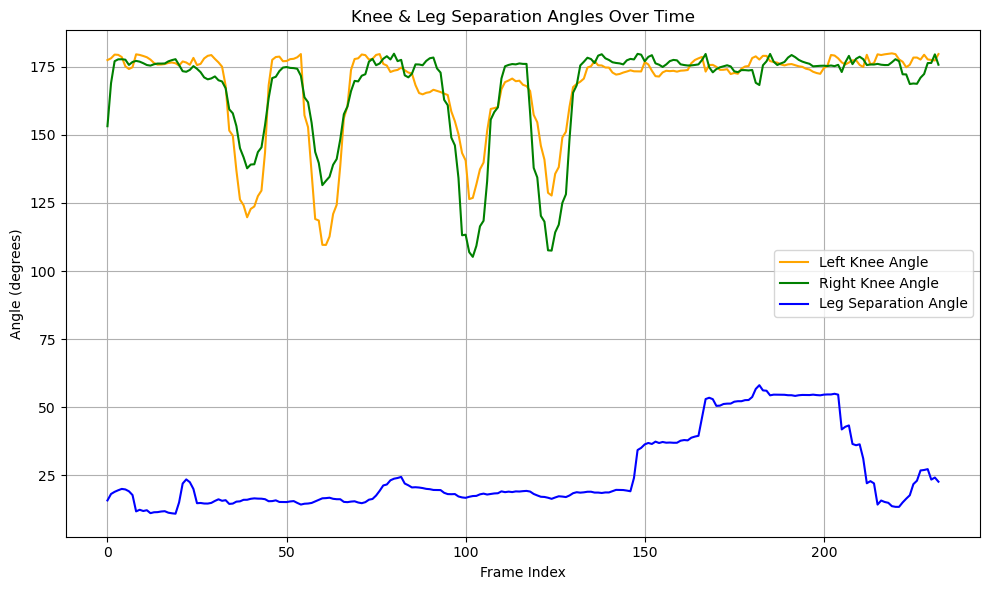

In [9]:
import cv2 
import mediapipe as mp
import numpy as np
import time
import pandas as pd
import json
import os
import matplotlib.pyplot as plt  # NEW: for plotting
from datetime import datetime

# === Initialization ===
angle_data = []
min_l_angle = 999
min_r_angle = 999
max_sep_angle = 0.0  # Track max leg separation

cap = cv2.VideoCapture(0)
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Create output directory if not exists
os.makedirs("output", exist_ok=True)

# === Function to calculate angle ===
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    if angle > 180:
        angle = 360 - angle
    return round(angle, 2)

# === Pose estimation loop ===
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        results = pose.process(image)

        # Convert back to BGR
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        try:
            landmarks = results.pose_landmarks.landmark

            # Extract points
            l_hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
            l_knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
                      landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            l_ankle = [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x,
                       landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y]

            r_hip = [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x,
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y]
            r_knee = [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x,
                      landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y]
            r_ankle = [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x,
                       landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y]

            # Calculate angles
            l_angle = calculate_angle(l_hip, l_knee, l_ankle)
            r_angle = calculate_angle(r_hip, r_knee, r_ankle)

            # Leg separation based on ankle X position difference
            ankle_sep = abs(l_ankle[0] - r_ankle[0])  # Normalized 0 to 1
            sep_angle = round(ankle_sep * 180, 2)     # Convert to angle-like scale

            # Update max separation
            if sep_angle > max_sep_angle:
                max_sep_angle = sep_angle

            # Update min angles
            if l_angle < min_l_angle:
                min_l_angle = l_angle
            if r_angle < min_r_angle:
                min_r_angle = r_angle

            # Print & store
            print(f"Left: {l_angle}, Right: {r_angle}, Separation: {sep_angle}")
            angle_data.append([datetime.now().strftime("%Y-%m-%d %H:%M:%S"), l_angle, r_angle, sep_angle])

            # === Visualizations ===
            # Angles in YELLOW
            cv2.putText(image, f"{l_angle}", tuple(np.multiply(l_knee, [640, 480]).astype(int)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 2)  # Yellow
            cv2.putText(image, f"{r_angle}", tuple(np.multiply(r_knee, [640, 480]).astype(int)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 2)  # Yellow

            # Min angles at bottom
            cv2.putText(image, f"Min L: {min_l_angle}", (10, 470),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)  # Blue
            cv2.putText(image, f"Min R: {min_r_angle}", (330, 470),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)  # Blue

            # Separation info
            cv2.putText(image, f"Sep: {sep_angle}", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
            cv2.putText(image, f"Max Sep: {max_sep_angle}", (470, 470),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        except Exception as e:
            print("❌", e)

        # Draw pose landmarks
        mp_drawing.draw_landmarks(
            image,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=2),  # Green joints
            mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2)   # Red lines
        )

        # Show the frame
        cv2.imshow("Knee Angles", image)

        # Exit with 'q'
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

# === Cleanup ===
cap.release()
cv2.destroyAllWindows()

# === Save data to CSV ===
if angle_data:
    df = pd.DataFrame(angle_data, columns=["Timestamp", "Left_Knee_Angle", "Right_Knee_Angle", "Leg_Separation_Angle"])
    df.to_csv("output/knee_angles.csv", index=False)
    print("✅ CSV saved: output/knee_angles.csv")
    print(f"✅ Lowest Left Knee Angle: {min_l_angle}")
    print(f"✅ Lowest Right Knee Angle: {min_r_angle}")
    print(f"✅ Max Leg Separation Angle: {max_sep_angle}")

    # === Save FINAL values to JSON for website ===
    avg_min_knee_angle = round((min_l_angle + min_r_angle) / 2, 2)
    final_summary = {
        "min_left_knee_angle": min_l_angle,
        "min_right_knee_angle": min_r_angle,
        "average_min_knee_angle": avg_min_knee_angle,  # NEW
        "max_leg_separation_angle": max_sep_angle
    }

    with open("output/latest_knee_angles.json", "w") as f:
        json.dump(final_summary, f)
    print("✅ Summary JSON saved: output/latest_knee_angles.json")
    print(f"✅ Average Min Knee Angle: {avg_min_knee_angle}")
    # === 📈 PLOT AND SAVE GRAPH ===
    try:
        plt.figure(figsize=(10, 6))
        plt.plot(df["Left_Knee_Angle"], label="Left Knee Angle", color="orange")
        plt.plot(df["Right_Knee_Angle"], label="Right Knee Angle", color="green")
        plt.plot(df["Leg_Separation_Angle"], label="Leg Separation Angle", color="blue")
        plt.title("Knee & Leg Separation Angles Over Time")
        plt.xlabel("Frame Index")
        plt.ylabel("Angle (degrees)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("output/knee_angle_plot.png")
        print("✅ Graph saved: output/knee_angle_plot.png")
    except Exception as e:
        print("⚠️ Error generating graph:", e)

else:
    print("⚠️ No angle data recorded. CSV not saved.")


